In [2]:
import numpy as np
import pandas as pd
import json
import gc
import re
import os
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# -------------------------------------------------------------------
# Generate Sample Data (replacing Kaggle dataset)
# -------------------------------------------------------------------

# Set random seed for reproducibility
np.random.seed(42)

# Create sample transaction data
n_transactions = 5000
transaction_ids = np.arange(1, n_transactions + 1)
user_ids = np.random.randint(1, 501, n_transactions)
card_ids = np.random.randint(1, 1001, n_transactions)
amounts = np.random.exponential(500, n_transactions)
mcc_codes = np.random.choice([1234, 1211, 1234, 1520, 5411, 5412, 5411, 6211, 6512, 7832, 8111], n_transactions)
timestamps = [datetime(2023, 1, 1) + timedelta(days=int(x)) for x in np.random.uniform(0, 365, n_transactions)]

transaction_df = pd.DataFrame({
    'transaction_id': transaction_ids,
    'user_id': user_ids,
    'card_id': card_ids,
    'amount': amounts,
    'mcc_code': mcc_codes,
    'timestamp': timestamps
})

# Create sample card data
card_ids_unique = np.arange(1, 1001)
card_df = pd.DataFrame({
    'card_id': card_ids_unique,
    'user_id': np.random.randint(1, 501, 1000),
    'card_type': np.random.choice(['credit', 'debit'], 1000),
    'issue_date': [datetime(2020, 1, 1) + timedelta(days=int(x)) for x in np.random.uniform(0, 1000, 1000)]
})

# Create sample user data
user_ids_unique = np.arange(1, 501)
users_df = pd.DataFrame({
    'user_id': user_ids_unique,
    'country': 'ZA',
    'registration_date': [datetime(2019, 1, 1) + timedelta(days=int(x)) for x in np.random.uniform(0, 1460, 500)]
})

# Create sample MCC codes dictionary
mcc_dict = {
    1234: 'Gasoline Stations',
    1211: 'Airlines',
    1520: 'General Contractors',
    5411: 'Grocery Stores',
    5412: 'Convenience Stores',
    6211: 'Securities Brokers',
    6512: 'Apartment/Condo Rental',
    7832: 'Movie Theatres',
    8111: 'Legal Services'
}

mcc_df = pd.DataFrame(list(mcc_dict.items()), columns=['mcc_code', 'description'])

# Create sample fraud labels (20% fraud rate)
fraud_labels = {str(tid): int(np.random.random() < 0.2) for tid in transaction_ids}

train_fraud_labels = pd.DataFrame(list(fraud_labels.items()), columns=['transaction_id', 'is_fraud'])
train_fraud_labels['transaction_id'] = pd.to_numeric(train_fraud_labels['transaction_id'])

print("\nAll sample data generated successfully.")

card_df.head()

card_df.shape


All sample data generated successfully.


(1000, 4)

In [3]:
transaction_df.head()

,transaction_id,user_id,card_id,amount,mcc_code,timestamp
0,1,103,904,171.276161,5412,2023-02-21
1,2,436,215,112.487564,8111,2023-05-18
2,3,349,974,154.084272,5411,2023-04-13
3,4,271,632,93.019751,6211,2023-11-11
4,5,107,894,50.264269,8111,2023-06-28


In [4]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  5000 non-null   int64         
 1   user_id         5000 non-null   int32         
 2   card_id         5000 non-null   int32         
 3   amount          5000 non-null   float64       
 4   mcc_code        5000 non-null   int64         
 5   timestamp       5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2)
memory usage: 195.4 KB


In [5]:
transaction_df.tail()

,transaction_id,user_id,card_id,amount,mcc_code,timestamp
4995,4996,111,836,167.635771,5411,2023-02-16
4996,4997,415,42,12.269445,1234,2023-11-28
4997,4998,290,915,490.440566,5411,2023-08-04
4998,4999,295,210,145.556348,5411,2023-09-27
4999,5000,451,741,552.748532,6512,2023-01-12


In [7]:
transaction_df.isnull().sum()

transaction_id    0
user_id           0
card_id           0
amount            0
mcc_code          0
timestamp         0
dtype: int64

In [9]:
transaction_df.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_id,5000.0,2500.5,1.0,1250.75,2500.5,3750.25,5000.0,1443.520003
user_id,5000.0,251.6706,1.0,128.0,253.0,379.0,500.0,144.570083
card_id,5000.0,502.2364,1.0,247.75,503.0,753.25,1000.0,288.641305
amount,5000.0,500.673019,0.092606,148.080217,349.694774,689.423152,4399.925574,506.088497
mcc_code,5000.0,4499.4448,1211.0,1234.0,5411.0,6512.0,8111.0,2601.783192
timestamp,5000,2023-06-30 10:14:35.520000,2023-01-01 00:00:00,2023-03-31 00:00:00,2023-06-30 00:00:00,2023-09-27 00:00:00,2023-12-31 00:00:00,NaN


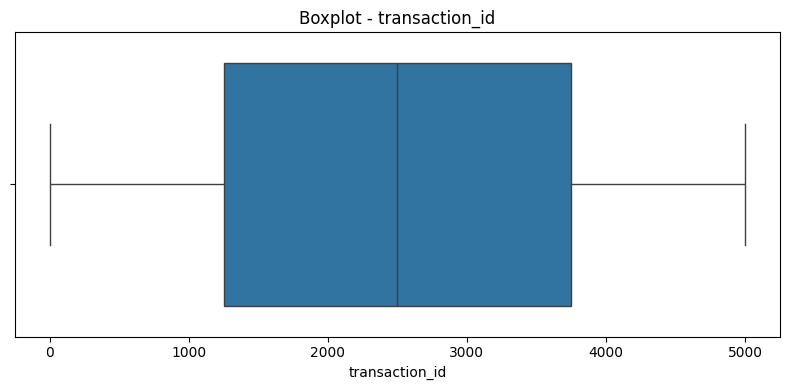

<Figure size 640x480 with 0 Axes>

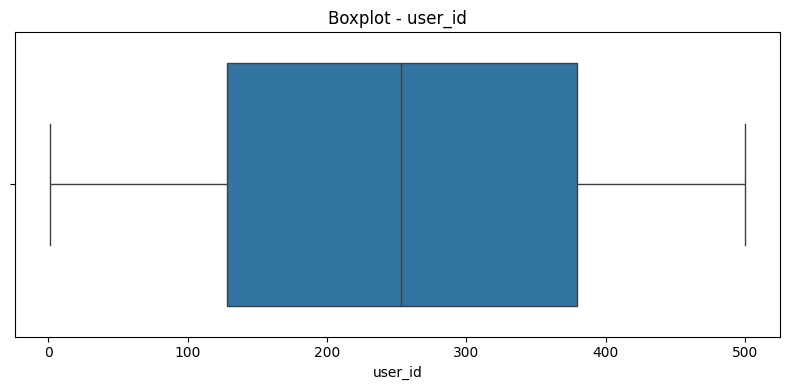

<Figure size 640x480 with 0 Axes>

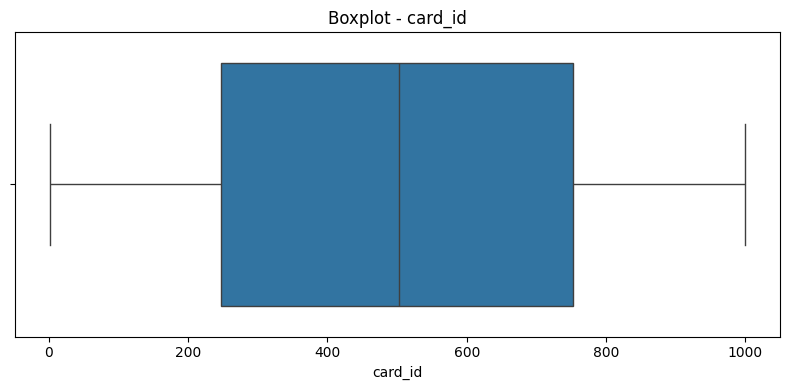

<Figure size 640x480 with 0 Axes>

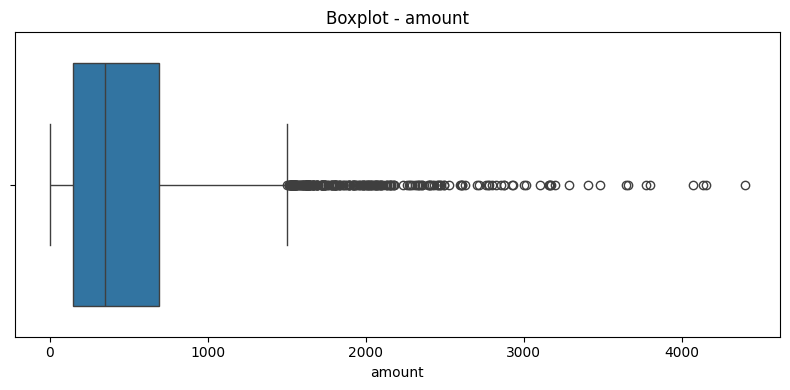

<Figure size 640x480 with 0 Axes>

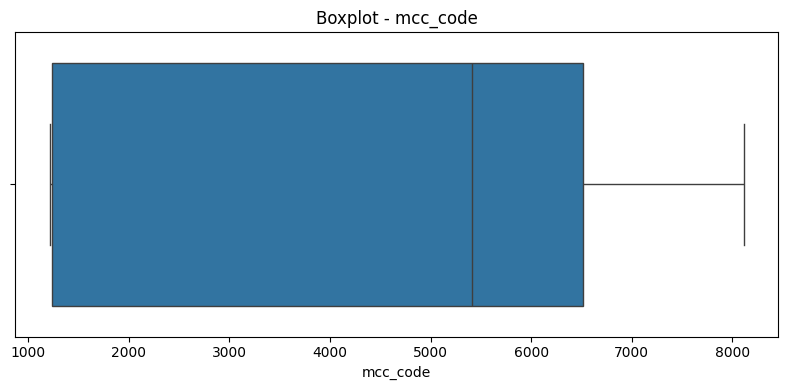

<Figure size 640x480 with 0 Axes>

In [12]:
# BOXPLOT TO IDENTIFY OUTLIERS
import warnings

warnings.filterwarnings("ignore")

for col in transaction_df.select_dtypes(include="number").columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=transaction_df, x=col)
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()
    plt.clf()